In [5]:
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D , MaxPooling2D , Flatten , Dense , Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split

ModuleNotFoundError: No module named 'cv2'

In [ ]:
def image_processing(image_path, img_size=(128, 128)):
    image_data = []
    labels = []
    classes = ['normal', 'blurred']

    for label in classes:
        class_path = os.path.join(image_path, label)
        # Ensure the class path exists
        if not os.path.exists(class_path):
            print(f'Directory does not exist: {class_path}')
            continue

        for img_name in os.listdir(class_path):
            try:
                img = cv2.imread(os.path.join(class_path, img_name), cv2.IMREAD_COLOR)

                # Check if the image was loaded correctly
                if img is None:
                    print(f'Failed to load image: {os.path.join(class_path, img_name)}')
                    continue  # Skip this image

                img = cv2.resize(img, img_size)
                img = img / 255.0
                image_data.append(img)
                labels.append(classes.index(label))

            except Exception as e:
                print(f'Error loading Image: {e}')

    return np.array(image_data), np.array(labels)

# Set the image path correctly
image_path = r'C:\Users\DELL\Desktop\0049\images'
x, y = image_processing(image_path)


In [ ]:
x_train , x_rem , y_train , y_rem = train_test_split(x , y , test_size = 0.3 , random_state = 42)

x_val , x_test , y_val , y_test = train_test_split(x , y , test_size = 0.5 , random_state 42)

In [ ]:
x_train.shape

(16000, 128, 128, 3)

In [ ]:
y_train.shape

(16000,)

In [ ]:
x_test.shape

(4000, 128, 128, 3)

In [ ]:
x_val.shape

In [ ]:
y_val.shape

In [ ]:
model = Sequential([
    Conv2D(32 , (3,3),activation = 'relu',input_shape = (128,128,3)),
    MaxPooling2D((2,2)),
    Conv2D(32 , (3,3) , activation = 'relu'),
    MaxPooling2D((2,2)),
    Conv2D(32 , (3,3) , activation = 'relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128 , activation = 'relu'),
    Dropout(0.5),
    Dense(1,activation = 'sigmoid')
])

C:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
base_model = tf.keras.applications.MobileNetV2(input_shape=(128, 128, 3),
                                               include_top=False,
                                               weights='imagenet')
model = Sequential([
    base_model,
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

In [ ]:
model.compile(optimizer = 'adam' ,
              loss = 'binary_crossentropy',
              metrics = ['accuracy'])

In [ ]:
data_aug = ImageDataGenerator(
    rotation_range = 20,
    width_shift_range = 0.2,
    height_shift_range = 0.2,
    horizontal_flip = True,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)
data_aug.fit(x_train)

In [ ]:
history = model.fit(data_aug.flow(x_train , y_train , batch_size = 32),epochs = 50 , validation_data = (x_val , y_val))

Epoch 1/15


C:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


500/500 ━━━━━━━━━━━━━━━━━━━━ 57s 109ms/step - accuracy: 0.7707 - loss: 0.4859 - val_accuracy: 0.9112 - val_loss: 0.3074
Epoch 2/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 54s 107ms/step - accuracy: 0.8994 - loss: 0.2834 - val_accuracy: 0.9158 - val_loss: 0.3391
Epoch 3/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 54s 107ms/step - accuracy: 0.9125 - loss: 0.2487 - val_accuracy: 0.9260 - val_loss: 0.1875
Epoch 4/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 55s 108ms/step - accuracy: 0.9194 - loss: 0.2123 - val_accuracy: 0.9277 - val_loss: 0.1787
Epoch 5/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 55s 109ms/step - accuracy: 0.9226 - loss: 0.2085 - val_accuracy: 0.9283 - val_loss: 0.2255
Epoch 6/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 54s 107ms/step - accuracy: 0.9240 - loss: 0.1948 - val_accuracy: 0.9247 - val_loss: 0.2323
Epoch 7/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 56s 111ms/step - accuracy: 0.9258 - loss: 0.1864 - val_accuracy: 0.9280 - val_loss: 0.4506
Epoch 8/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 56s 111ms/step - accuracy: 0.9261 - loss: 0.1907 - val

In [ ]:
loss, accuracy = model.evaluate(x_test, y_test)
print(f'Test Accuracy: {accuracy * 100:.2f}%')




NameError: name 'x_test' is not defined

# Accuracy of model is aorund 92% on validation Dataset

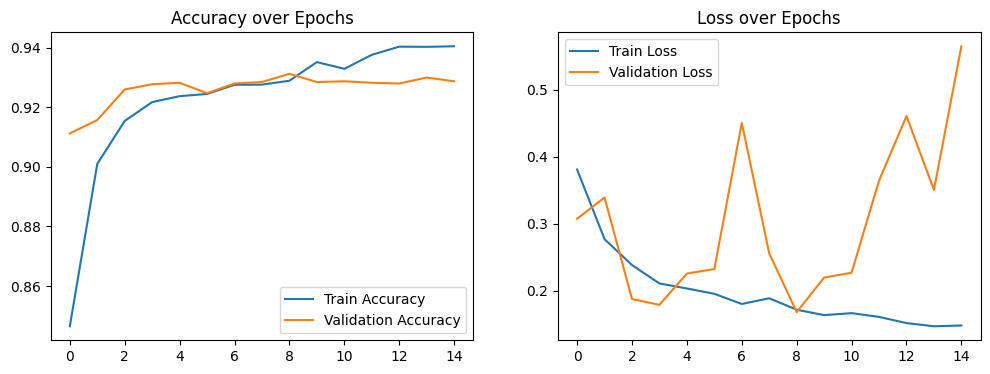

In [ ]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy over Epochs')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss over Epochs')
plt.show()

In [ ]:
model = tf.keras.models.load_model("/content/drive/MyDrive/Final-Year_Project/blur_detection_cnn_model.h5")
img_path = "/content/drive/MyDrive/Final-Year_Project/test_images/blurimg4.jpeg"

def predict_image(model, img_path):
    if not os.path.exists(img_path):
        print(f"Error: The image file '{img_path}' does not exist.")
        return
    img = cv2.imread(img_path, cv2.IMREAD_COLOR)
    if img is None:
        print(f"Error: Unable to read the image file '{img_path}'. Please check the file format and path.")
        return

    img = cv2.resize(img, (128, 128))
    img = np.expand_dims(img / 255.0, axis=0)
    prediction = model.predict(img)
    print(prediction)
    if prediction < 0.5:
        print("The image is classified as Normal.")
    else:
        print("The image is classified as Blurred.")

predict_image(model, img_path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step
[[0.97854817]]
The image is classified as Blurred.


In [4]:
import os
import cv2
import numpy as np
import tensorflow as tf
from google.colab.patches import cv2_imshow


model = tf.keras.models.load_model("/content/drive/MyDrive/Final-Year_Project/blur_detection_cnn_model.h5")

def predict_video(model, video_path):
    if not os.path.exists(video_path):
        print(f"Error: The video file '{video_path}' does not exist.")
        return

    cap = cv2.VideoCapture(video_path)

    frame_count = 0
    blurred_count = 0
    normal_count = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break


        img = cv2.resize(frame, (128, 128))
        img = np.expand_dims(img / 255.0, axis=0)

        prediction = model.predict(img)
        print(f"Frame {frame_count}: Prediction = {prediction[0][0]}")

        # Check prediction and classify frame
        if prediction < 0.5:
            print(f"Frame {frame_count} is classified as Normal.")
            normal_count += 1
        else:
            print(f"Frame {frame_count} is classified as Blurred.")
            blurred_count += 1

        cv2.putText(frame, f'{"Normal" if prediction < 0.5 else "Blurred"}', (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

##################################################

#If You want want to display the frames also then uncomment the following line

        #cv2_imshow(frame)

##################################################

        frame_count += 1

        # Break the loop if 'q' is pressed
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()

    print(f"Total Normal Frames: {normal_count}")
    print(f"Total Blurred Frames: {blurred_count}")

# Specify the path to your video file
video_path = '/Users/admin/Downloads/WhatsApp Video 2025-05-02 at 15.24.59.mp4'
predict_video(model, video_path)


ModuleNotFoundError: No module named 'cv2'